In [1]:
from google.colab import files
uploaded = files.upload()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset.csv


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [6]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")


In [7]:
print(df.columns)

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')


In [8]:
print(df.head())

   age  gender  ...  addiction_level depression_label
0   14    male  ...                1                0
1   19  female  ...               10                0
2   17  female  ...                2                0
3   15    male  ...                9                0
4   15  female  ...                2                0

[5 rows x 13 columns]


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB
None

In [10]:
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [11]:
print("\nDUPLICATE VALUES")
print(df.duplicated().sum())



DUPLICATE VALUES
0


In [12]:
print(df.dtypes)


age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [73]:
print(df["depression_label"].value_counts())

depression_label
0    1169
1      31
Name: count, dtype: int64


In [22]:
y = df["depression_label"]

In [23]:
x = df.drop("depression_label",axis=1)

In [24]:
x = pd.get_dummies(x,drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [67]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred = model.predict(x)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

Logistic Regression Accuracy: 0.9916666666666667


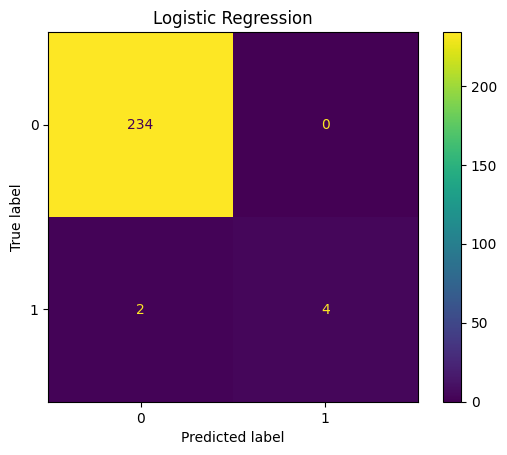

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = model.predict(x_test)

logistic_acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", logistic_acc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression")
plt.show()

print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.9916666666666667


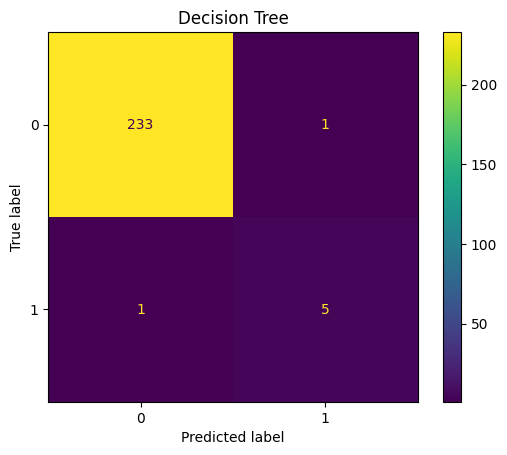

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



In [60]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

decison_acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", decison_acc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Decision Tree")
plt.show()

print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9791666666666666


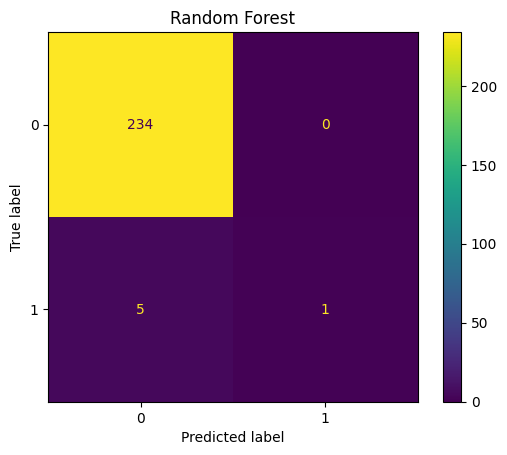

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

randomforest_acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", randomforest_acc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest")
plt.show()

print(classification_report(y_test, y_pred))

KNN Accuracy: 0.9791666666666666


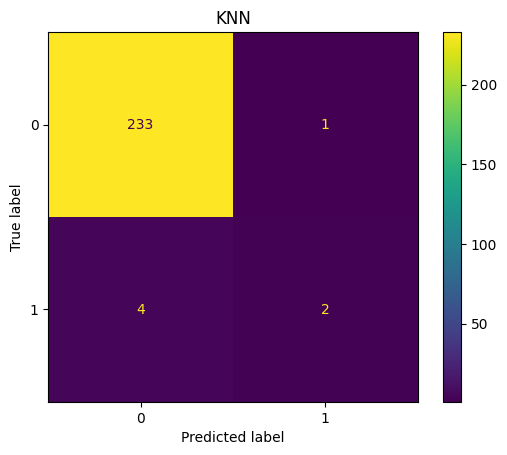

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       0.67      0.33      0.44         6

    accuracy                           0.98       240
   macro avg       0.82      0.66      0.72       240
weighted avg       0.98      0.98      0.98       240



In [56]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

Knn_acc = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", Knn_acc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("KNN")
plt.show()

print(classification_report(y_test, y_pred))

SVC Accuracy: 0.975


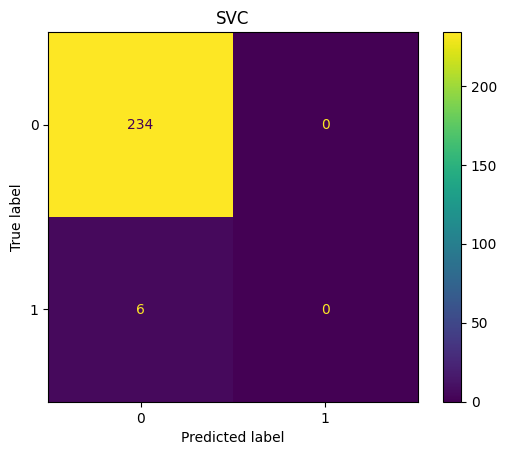

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [57]:
from sklearn.svm import SVC

model = SVC()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

svc_acc = accuracy_score(y_test, y_pred)
print("SVC Accuracy:", svc_acc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVC")
plt.show()

print(classification_report(y_test, y_pred))

Naive Bayes Accuracy: 0.9916666666666667


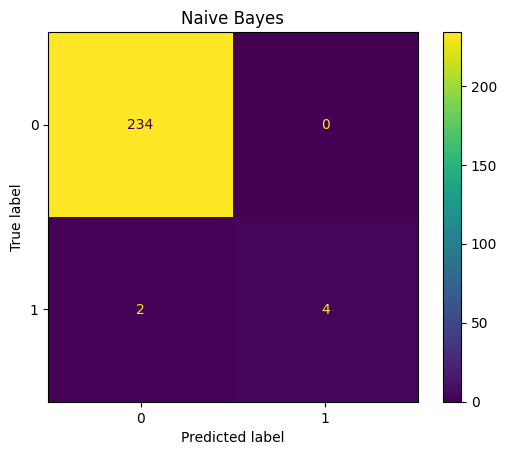

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



In [58]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

naive_acc = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", naive_acc)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Naive Bayes")
plt.show()

print(classification_report(y_test, y_pred))

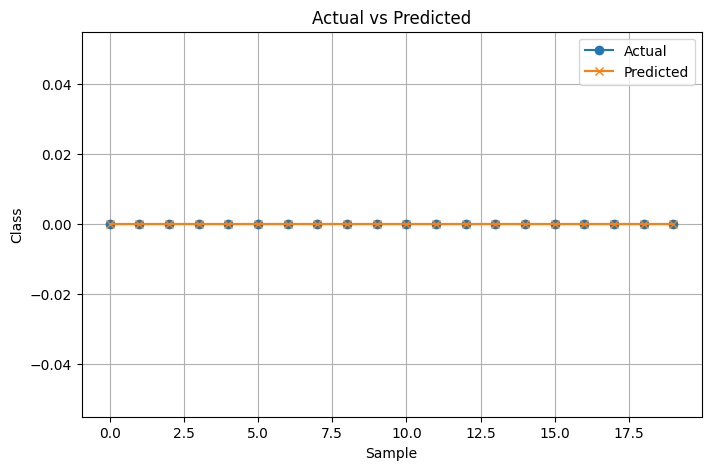

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(y_test.values[:20], marker='o', label='Actual')
plt.plot(y_pred[:20], marker='x', label='Predicted')

plt.title("Actual vs Predicted")
plt.xlabel("Sample")
plt.ylabel("Class")
plt.legend()
plt.grid(True)
plt.show()

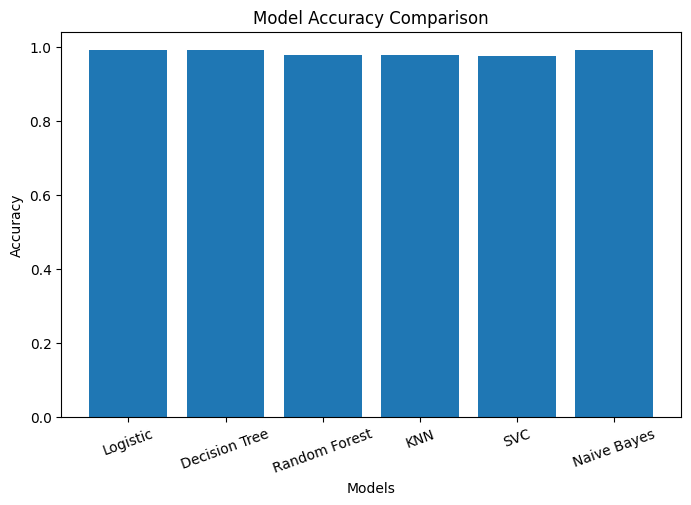

In [63]:
import matplotlib.pyplot as plt

models = ["Logistic", "Decision Tree", "Random Forest", "KNN", "SVC", "Naive Bayes"]
accuracies = [
    logistic_acc,
    decison_acc,
    randomforest_acc,
    Knn_acc,
    svc_acc,
    naive_acc
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [64]:
best_model = models[accuracies.index(max(accuracies))]
print("Best Model:", best_model)
print("Best Accuracy:", max(accuracies))

Best Model: Logistic
Best Accuracy: 0.9916666666666667


In [69]:
y_pred = model.predict(x_test)
print("Predicted Target Values:")
print(y_pred)

Predicted Target Values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [70]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


In [75]:
print("Classification project completed successfully.")
print("The best performing model is:", best_model)

Classification project completed successfully.
The best performing model is: Logistic
